In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve, 
                             precision_recall_curve,
                             average_precision_score,
                             confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print("✅ Libraries loaded")
print(f"LightGBM version: {lgb.__version__}")

✅ Libraries loaded
LightGBM version: 4.7.0


In [2]:
df = pd.read_csv('../data/df_model.csv')

print(f"Dataset shape: {df.shape}")
print(f"Default rate: {df['target'].mean()*100:.1f}%")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (1345350, 15)
Default rate: 20.0%

Columns: ['int_rate', 'fico_range_high', 'fico_range_low', 'loan_to_income', 'installment_to_income', 'dti', 'loan_amnt', 'issue_year', 'installment', 'annual_inc', 'revol_util', 'target', 'issue_d', 'grade', 'loan_amnt.1']


In [ ]:
from sklearn.model_selection import train_test_split


# so time-based split not meaningful here
# Full dataset on Kaggle will use proper time-based split
# For local development we use stratified random split

feature_cols = [
    'int_rate', 'loan_to_income', 'fico_range_high',
    'fico_range_low', 'installment_to_income', 'dti',
    'loan_amnt', 'installment', 'inq_last_6mths', 'annual_inc'
]

# Keep only features that exist in dataframe
feature_cols = [f for f in feature_cols if f in df.columns]

X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=32,
    stratify=y  # maintains 80/20 class ratio in both splits
)

print(f"Features used: {feature_cols}")
print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"\nTrain default rate: {y_train.mean()*100:.1f}%")
print(f"Test default rate:  {y_test.mean()*100:.1f}%")

Features used: ['int_rate', 'loan_to_income', 'fico_range_high', 'fico_range_low', 'installment_to_income', 'dti', 'loan_amnt', 'installment', 'annual_inc']

Train shape: (941745, 9)
Test shape:  (403605, 9)

Train default rate: 20.0%
Test default rate:  20.0%


In [4]:
print("df shape:", df.shape)
print("issue_d sample:", df['issue_d'].head())
print("issue_d dtype:", df['issue_d'].dtype)
print("\nDate range:")
print("Min:", df['issue_d'].min())
print("Max:", df['issue_d'].max())
print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

df shape: (1345350, 15)
issue_d sample: 0    2015-12-01
1    2015-12-01
2    2015-12-01
3    2015-12-01
4    2015-12-01
Name: issue_d, dtype: str
issue_d dtype: str

Date range:
Min: 2007-06-01
Max: 2018-12-01

Train shape: (941745, 9)
Test shape: (403605, 9)


In [5]:
# Calculate class weight to handle imbalance
# 80% paid, 20% default → weight defaults 4x more
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Negative samples: {neg_count:,}")
print(f"Positive samples: {pos_count:,}")
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# LightGBM parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'scale_pos_weight': scale_pos_weight,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

# Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data  = lgb.Dataset(X_test,  label=y_test, reference=train_data)

# Train with early stopping
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[test_data],
    callbacks=callbacks
)

print(f"\n✅ Model trained")
print(f"Best iteration: {model.best_iteration}")

Negative samples: 753,726
Positive samples: 188,019
Scale pos weight: 4.01
[100]	valid_0's auc: 0.707018
[200]	valid_0's auc: 0.708488
[300]	valid_0's auc: 0.709129
[400]	valid_0's auc: 0.709507
[500]	valid_0's auc: 0.709893
[600]	valid_0's auc: 0.709982
[700]	valid_0's auc: 0.710083

✅ Model trained
Best iteration: 688


In [6]:
# Get predictions
y_pred_proba = model.predict(X_test)
y_pred_binary = (y_pred_proba >= 0.5).astype(int)

# 1. AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)

# 2. Gini coefficient
gini = 2 * auc - 1

# 3. KS Statistic
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ks_stat = max(tpr - fpr)

# 4. Average Precision
avg_precision = average_precision_score(y_test, y_pred_proba)

print("=" * 45)
print("MODEL PERFORMANCE")
print("=" * 45)
print(f"AUC-ROC:           {auc:.4f}")
print(f"Gini Coefficient:  {gini:.4f}")
print(f"KS Statistic:      {ks_stat:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print("=" * 45)

# Interpretation
print(f"\nGini Interpretation:")
if gini > 0.6:
    print("  Excellent — strong rank ordering")
elif gini > 0.4:
    print("  Good — acceptable for credit risk")
else:
    print("  Weak — needs improvement")

MODEL PERFORMANCE
AUC-ROC:           0.7101
Gini Coefficient:  0.4202
KS Statistic:      0.3043
Average Precision: 0.3705

Gini Interpretation:
  Good — acceptable for credit risk


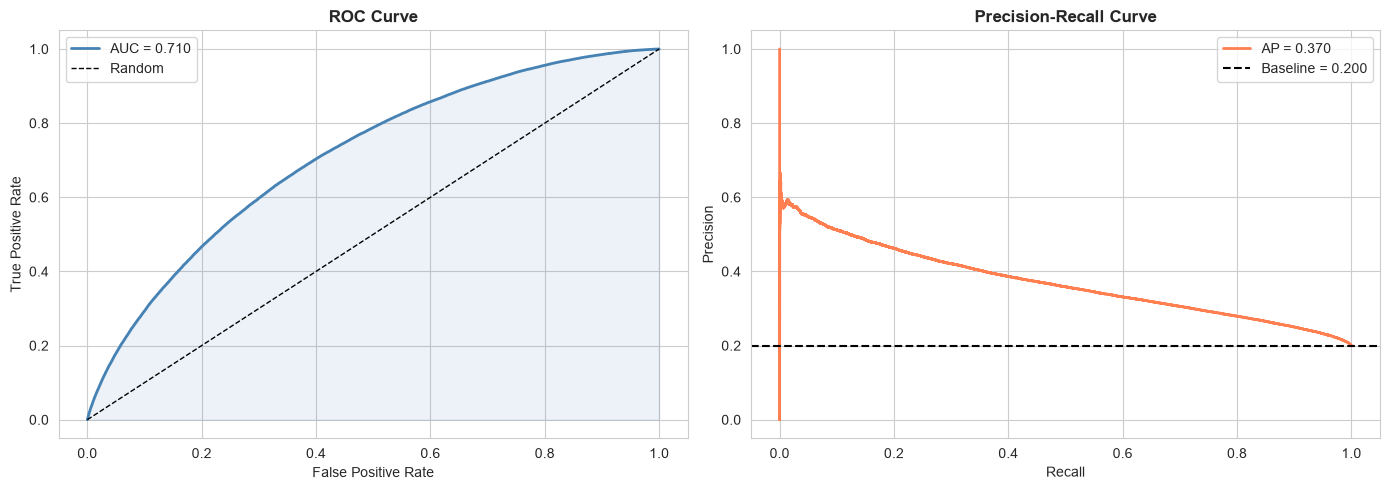

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'AUC = {auc:.3f}')
axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(recall, precision, color='coral', lw=2,
             label=f'AP = {avg_precision:.3f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--',
                label=f'Baseline = {y_test.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../notebooks/images/06_roc_pr_curves.png', dpi=150)
plt.show()

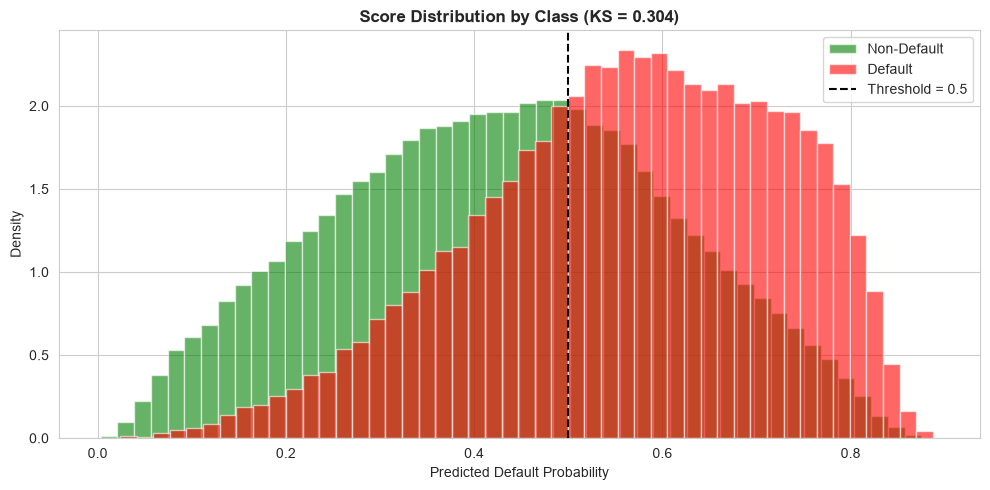

In [8]:
# KS Chart — standard in banking model validation
# Shows separation between default and non-default score distributions

from scipy import stats

# Scores for each class
scores_default  = y_pred_proba[y_test == 1]
scores_nondefault = y_pred_proba[y_test == 0]

plt.figure(figsize=(10, 5))
plt.hist(scores_nondefault, bins=50, alpha=0.6, 
         color='green', label='Non-Default', density=True)
plt.hist(scores_default, bins=50, alpha=0.6,
         color='red', label='Default', density=True)
plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold = 0.5')
plt.xlabel('Predicted Default Probability')
plt.ylabel('Density')
plt.title(f'Score Distribution by Class (KS = {ks_stat:.3f})', 
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/images/07_ks_chart.png', dpi=150)
plt.show()

Credit Score Distribution:
  Min score:    447
  Max score:    850
  Mean score:   616
  Median score: 611

Score by actual outcome:
  Non-defaulters avg score: 624
  Defaulters avg score:     580


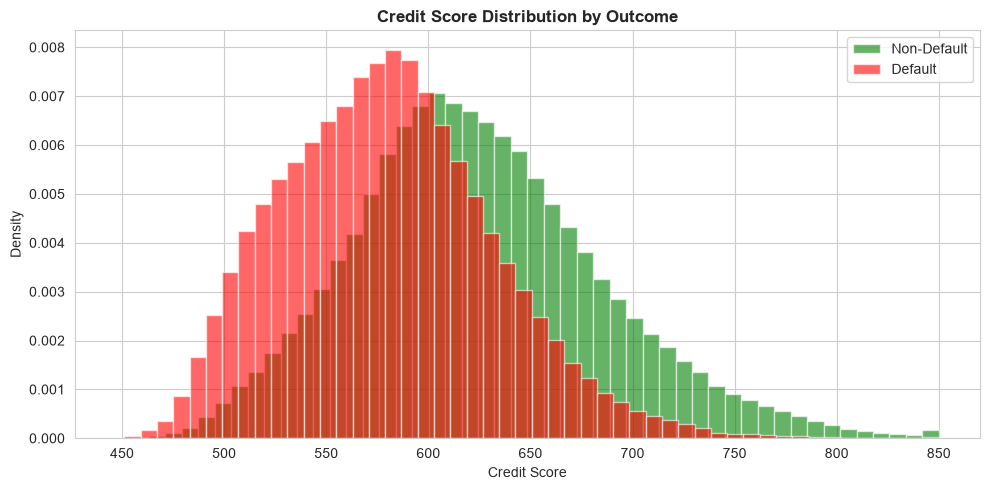

In [9]:
# Convert probability to 300-850 score like FICO
# Standard formula: Score = Offset + Factor × log(odds)
# We calibrate so:
#   probability 0.5  → score ~600 (medium risk)
#   probability 0.05 → score ~750 (low risk)  
#   probability 0.9  → score ~400 (high risk)

def probability_to_score(prob, 
                          base_score=600,
                          base_odds=1,
                          pdo=50):
    """
    Convert default probability to credit score
    pdo = points to double the odds
    Higher score = lower risk (like FICO)
    """
    # Clip to avoid log(0)
    prob = np.clip(prob, 0.001, 0.999)
    
    # Odds = probability of good / probability of bad
    odds = (1 - prob) / prob
    
    # Score formula
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    score = offset + factor * np.log(odds)
    
    # Clip to 300-850 range
    score = np.clip(score, 300, 850)
    return score

# Apply to test set
test_scores = probability_to_score(y_pred_proba)

print("Credit Score Distribution:")
print(f"  Min score:    {test_scores.min():.0f}")
print(f"  Max score:    {test_scores.max():.0f}")
print(f"  Mean score:   {test_scores.mean():.0f}")
print(f"  Median score: {np.median(test_scores):.0f}")

print(f"\nScore by actual outcome:")
print(f"  Non-defaulters avg score: {test_scores[y_test==0].mean():.0f}")
print(f"  Defaulters avg score:     {test_scores[y_test==1].mean():.0f}")

# Plot score distribution
plt.figure(figsize=(10, 5))
plt.hist(test_scores[y_test==0], bins=50, alpha=0.6,
         color='green', label='Non-Default', density=True)
plt.hist(test_scores[y_test==1], bins=50, alpha=0.6,
         color='red', label='Default', density=True)
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.title('Credit Score Distribution by Outcome', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/images/08_score_distribution.png', dpi=150)
plt.show()

In [10]:
# Standard banking model validation technique
# Split predictions into 10 equal groups (deciles)
# Decile 1 = highest risk, Decile 10 = lowest risk

test_results = pd.DataFrame({
    'actual': y_test.values,
    'predicted_proba': y_pred_proba,
    'credit_score': test_scores
})

# Assign deciles (1 = highest risk)
test_results['decile'] = pd.qcut(
    test_results['predicted_proba'],
    q=10,
    labels=range(10, 0, -1)
)

decile_analysis = test_results.groupby('decile', observed=True).agg(
    total_loans=('actual', 'count'),
    defaults=('actual', 'sum'),
    default_rate=('actual', 'mean'),
    avg_score=('credit_score', 'mean'),
    avg_prob=('predicted_proba', 'mean')
).reset_index()

decile_analysis['default_rate_pct'] = (
    decile_analysis['default_rate'] * 100
).round(2)
decile_analysis['cumulative_default_rate'] = (
    decile_analysis['defaults'].cumsum() / 
    decile_analysis['defaults'].sum() * 100
).round(2)

print("Decile Analysis:")
print(decile_analysis[[
    'decile', 'total_loans', 'defaults',
    'default_rate_pct', 'avg_score', 
    'cumulative_default_rate'
]].to_string(index=False))

Decile Analysis:
decile  total_loans  defaults  default_rate_pct  avg_score  cumulative_default_rate
    10        40361      1576              3.90 736.059783                     1.96
     9        40360      3036              7.52 679.771069                     5.72
     8        40361      4314             10.69 653.766453                    11.08
     7        40360      5469             13.55 634.765610                    17.86
     6        40361      6632             16.43 618.425427                    26.09
     5        40360      7771             19.25 603.567073                    35.74
     4        40360      9260             22.94 589.010256                    47.23
     3        40361     11066             27.42 572.929752                    60.96
     2        40360     13288             32.92 551.572890                    77.45
     1        40361     18168             45.01 516.084256                   100.00


In [11]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save model
model.save_model('../models/pd_model.txt')

# Save feature list
import json
with open('../models/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

# Save test results for SHAP notebook
test_results['actual'] = y_test.values
test_results.to_csv('../data/test_results.csv', index=False)

print("✅ Model saved to models/pd_model.txt")
print("✅ Features saved to models/feature_cols.json")
print("✅ Test results saved to data/test_results.csv")

✅ Model saved to models/pd_model.txt
✅ Features saved to models/feature_cols.json
✅ Test results saved to data/test_results.csv
